This project aims to build a machine learning model to classify SMS messages as spam or ham (not spam). Spam detection is important to filter unwanted messages and improve user experience.

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("spam.csv", encoding='latin1')

In [3]:
data.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
624,ham,"Nah it's straight, if you can just bring bud o...",NaN,NaN,NaN
4685,ham,But pls dont play in others life.,NaN,NaN,NaN
1085,ham,FR'NDSHIP is like a needle of a clock. Though ...,NaN,NaN,NaN
3577,ham,They said Ì_ dun haf passport or smth like dat...,NaN,NaN,NaN
4751,ham,Well boy am I glad G wasted all night at apple...,NaN,NaN,NaN
4573,ham,:( but your not here....,NaN,NaN,NaN
3619,ham,I meant as an apology from me for texting you ...,NaN,NaN,NaN
5042,ham,O ic lol. Should play 9 doors sometime yo,NaN,NaN,NaN
3544,ham,Thank You meet you monday,NaN,NaN,NaN
3644,spam,wamma get laid?want real doggin locations sent...,NaN,NaN,NaN


We begin by loading the dataset and performing initial cleaning steps such as removing unnecessary columns and renaming columns for clarity.

In [4]:
data.drop(columns = ["Unnamed: 2","Unnamed: 3", "Unnamed: 4"], inplace = True)

In [5]:
data.rename(columns = {"v1":"label", "v2":"text"}, inplace = True)

In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
enc = LabelEncoder()

In [8]:
data["label"] = enc.fit_transform(data["label"])

In [9]:
data.sample(10)

,label,text
2248,0,will you like to be spoiled? :)
5093,0,Gokila is talking with you aha:)
5213,0,3 pa but not selected.
4823,0,Not thought bout it... || Drink in tap & spile...
3822,0,Please protect yourself from e-threats. SIB ne...
3923,0,How? Izzit still raining?
5143,0,Hi darlin im on helens fone im gonna b up the ...
3989,1,(Bank of Granite issues Strong-Buy) EXPLOSIVE ...
5340,0,Are u awake? Is there snow there?
248,0,It didnt work again oh. Ok goodnight then. I.l...


In [43]:
data = data.drop_duplicates(keep="first")

In [44]:
import nltk

In [45]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\91987\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [46]:
data["num_characters"] = data["text"].apply(len)

In [47]:
data.head()

,label,text,num_characters,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah think goe usf live around though


Text data needs to be cleaned before feeding into machine learning models. We perform:
- Lowercasing
- Tokenization
- Removal of stopwords and punctuation
- Stemming

In [48]:
data["text"].apply(lambda x:nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [49]:
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91987\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [50]:
import string
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

In [51]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [52]:
transform_text("I loved the YT lecture of ML!")

'love yt lectur ml'

In [53]:
data["transformed_text"] = data["text"].apply(transform_text)

In [54]:
data.head()

,label,text,num_characters,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah think goe usf live around though


In [55]:
spam_corpus = []
for msg in data[data["label"] == 1]["transformed_text"].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [56]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

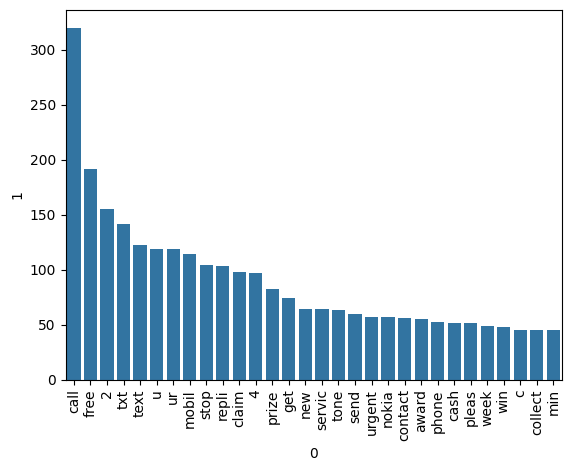

In [57]:
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation = "vertical")
plt.show()

In [58]:
ham_corpus = []
for msg in data[data["label"] == 0]["transformed_text"].tolist():
    for word in msg.split():
        ham_corpus.append(word)

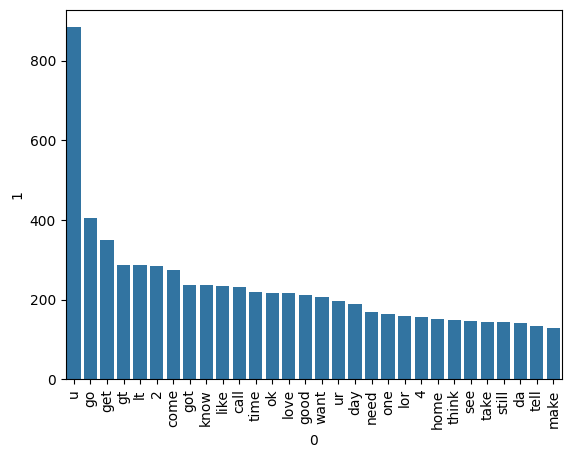

In [59]:
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation = "vertical")
plt.show()

We convert text into numerical form using TF-IDF Vectorization. We also use n-grams to capture word combinations like "free offer".

In [60]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf  = TfidfVectorizer(ngram_range = (1,2),max_features = 5000)

In [61]:
x = tfidf.fit_transform(data["transformed_text"]).toarray()
y = data["label"].values

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

We experiment with multiple Naive Bayes models:
- GaussianNB
- MultinomialNB
- BernoulliNB

In [64]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [65]:
gnb = GaussianNB()
mnb = MultinomialNB()
mnb_tuned = MultinomialNB(alpha = 0.1)
bnb = BernoulliNB()

In [66]:
from sklearn.metrics import classification_report

We evaluate models using:
- Accuracy
- Precision (important for spam detection)
- Recall
- F1-score

Precision is important because we want to avoid marking normal messages as spam.

In [67]:
gnb.fit(x_train, y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))
print(classification_report(y_test, y_pred1))

0.9090909090909091
[[820  76]
 [ 18 120]]
0.6122448979591837
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       896
           1       0.61      0.87      0.72       138

    accuracy                           0.91      1034
   macro avg       0.80      0.89      0.83      1034
weighted avg       0.93      0.91      0.92      1034



In [68]:
mnb.fit(x_train, y_train)
y_pred2 = mnb.predict(x_test)
y_prob = mnb.predict_proba(x_test)[:,1]
y_pred_new = (y_prob > 0.3).astype(int)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))
print(classification_report(y_test, y_pred_new))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       896
           1       0.98      0.86      0.91       138

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



Initially, the model had high precision but lower recall for spam detection. To improve performance:
- Decision threshold was reduced from 0.5 to 0.3
- Alpha parameter in MultinomialNB was tuned

This improved recall while maintaining high precision, resulting in a better F1-score.

In [70]:
mnb_tuned.fit(x_train, y_train)
y_pred2 = mnb_tuned.predict(x_test)
y_prob = mnb_tuned.predict_proba(x_test)[:,1]
y_pred_new = (y_prob > 0.3).astype(int)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))
print(classification_report(y_test, y_pred_new))

0.9806576402321083
[[892   4]
 [ 16 122]]
0.9682539682539683
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       896
           1       0.94      0.90      0.92       138

    accuracy                           0.98      1034
   macro avg       0.96      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [71]:
bnb.fit(x_train, y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))
print(classification_report(y_test, y_pred3))

0.9777562862669246
[[896   0]
 [ 23 115]]
1.0
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       896
           1       1.00      0.83      0.91       138

    accuracy                           0.98      1034
   macro avg       0.99      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034



Multinomial Naive Bayes with tuned alpha and threshold was selected as the final model due to its balanced performance.

In [72]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))

In [73]:
pickle.dump(mnb_tuned,open('model_tuned.pkl', 'wb'))

The final model achieves high accuracy and a strong balance between precision and recall, making it effective for spam detection. Further improvements could include using advanced models like Logistic Regression or deep learning approaches.